In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import numpy as np
import trimesh
import stltovoxel
import cascadio
import glob
import sys
import os
import shutil
from pathlib import Path
from PIL import Image

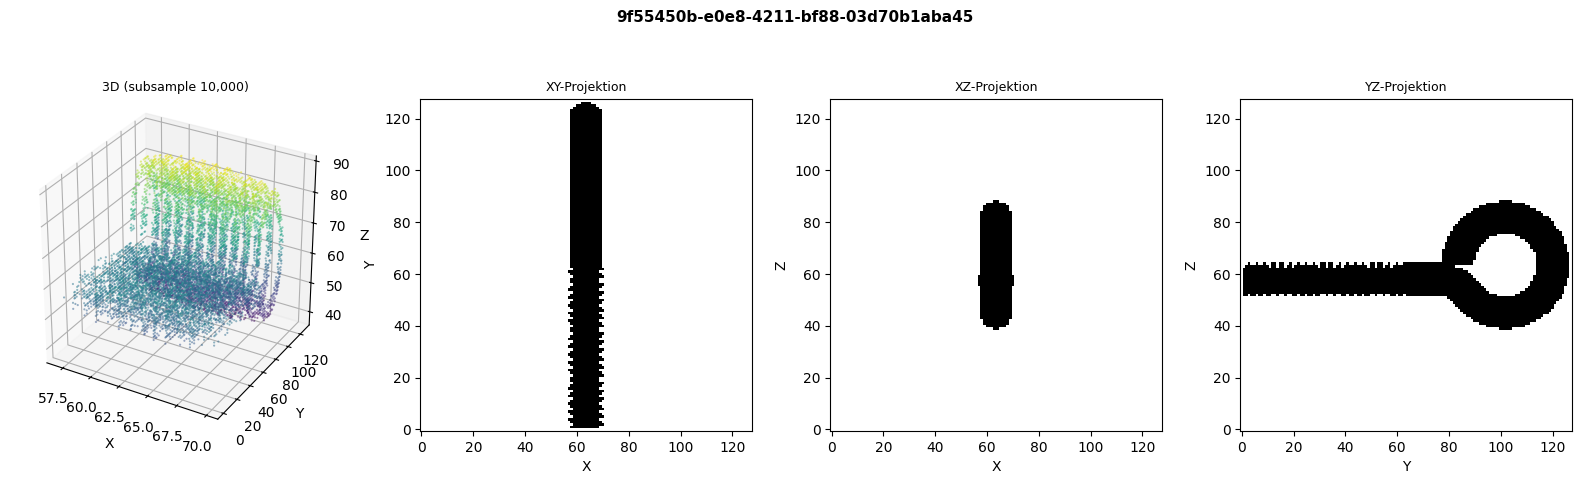

In [18]:
def load_and_visualize_voxel(npz_path: str | Path, max_points: int = 10_000):
    """
    Lädt eine .npz Voxeldatei und visualisiert sie auf zwei Arten:
    1. 3D-Scatter der besetzten Voxel
    2. 3 orthogonale Schnittansichten (XY, XZ, YZ)
    """
    # --- Laden ---
    npz_path = Path(npz_path)
    data = np.load(npz_path, allow_pickle=True)
    
    indices    = data["indices"]        # shape (N, 3)
    voxel_shape = tuple(data["shape"]) # z.B. (128, 128, 128)
    resolution  = float(data["resolution"])
    
    # Binäres Grid rekonstruieren
    grid = np.zeros(voxel_shape, dtype=bool)
    grid[indices[:, 0], indices[:, 1], indices[:, 2]] = True
    
    occupancy = indices.shape[0] / np.prod(voxel_shape) * 100
    print(f"Datei      : {npz_path.name}")
    print(f"Shape      : {voxel_shape}")
    print(f"Resolution : {resolution}")
    print(f"Besetzte Voxel: {indices.shape[0]:,} / {np.prod(voxel_shape):,} ({occupancy:.2f}%)")
    
    fig = plt.figure(figsize=(16, 5))
    
    # --- Plot 1: 3D Scatter ---
    ax1 = fig.add_subplot(1, 4, 1, projection="3d")
    
    # Subsample falls zu viele Punkte
    pts = indices
    if len(pts) > max_points:
        idx = np.random.choice(len(pts), max_points, replace=False)
        pts = pts[idx]
        ax1.set_title(f"3D (subsample {max_points:,})", fontsize=9)
    else:
        ax1.set_title("3D Voxel", fontsize=9)
    
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                s=0.3, c=pts[:, 2], cmap="viridis", alpha=0.5)
    ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
    ax1.set_box_aspect([1, 1, 1])
    
    # --- Plots 2-4: Orthogonale Projektionen ---
    projections = [
        (grid.any(axis=2), "XY-Projektion", "X", "Y"),
        (grid.any(axis=1), "XZ-Projektion", "X", "Z"),
        (grid.any(axis=0), "YZ-Projektion", "Y", "Z"),
    ]
    
    for i, (proj, title, xlabel, ylabel) in enumerate(projections):
        ax = fig.add_subplot(1, 4, i + 2)
        ax.imshow(proj.T, origin="lower", cmap="binary", interpolation="nearest")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    
    plt.suptitle(npz_path.stem, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return grid


# --- Aufruf ---
grid = load_and_visualize_voxel("/clear-shape/data/4_feature/voxel/fabwave/Routing EyeBolts Bent Closed Eye/9f55450b-e0e8-4211-bf88-03d70b1aba45.npz")